# **Домашнее задание №1 (base). Часть 1**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error as MSE
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from ydata_profiling import ProfileReport

random.seed(42)
np.random.seed(42)

Давайте зафиксируем важный момент.

**Задание 0 (0 баллов).**
Изучите и ответье на вопрос: для чего фиксируем сиды в домашках?

Фиксируем сиды для одинаковых случайных чисел

# **Часть 1 | EDA и визуализация**


## **Простейший EDA и обработка признаков (2.5 балла)**

In [ ]:
df_train = pd.read_csv('https://raw.githubusercontent.com/Murcha1990/MLDS_ML_2022/main/Hometasks/HT1/cars_train.csv')
df_test = pd.read_csv('https://raw.githubusercontent.com/Murcha1990/MLDS_ML_2022/main/Hometasks/HT1/cars_test.csv')

print("Train data shape:", df_train.shape)
print("Test data shape: ", df_test.shape)

Train data shape: (6999, 13)
Test data shape:  (1000, 13)


In [ ]:
print(df_train.sample(n=30))
print('---')
print(df_train.head())
print('---')
print(df_train.tail())
print('---')
print(df_train.isnull().sum())
print('---')
print(df_train.duplicated().sum())

                                        name  year  selling_price  km_driven  \
6565        Renault KWID Climber 1.0 MT BSIV  2019         300000      35000   
2943                      Maruti Wagon R LXI  2013         225000      58343   
2024                    Hyundai i20 Asta 1.2  2013         360000      30000   
263                     Hyundai i20 1.2 Asta  2010         300000      70000   
4586        Skoda Octavia L and K 1.9 TDI MT  2005         250000     120000   
4479                         Maruti Ciaz ZXi  2016         700000      20000   
4881  Hyundai Grand i10 1.2 Kappa Magna BSIV  2017         445000      27000   
3583          Ford Ecosport 1.5 DV5 MT Trend  2016         515000      68609   
6361                  Hyundai Verna 1.4 VTVT  2014         500000      33400   
4108                     Hyundai i20 Era 1.2  2015         490000      45900   
132          Mercedes-Benz S-Class S 350 CDI  2017        5850000      47000   
6974  Fiat Grande Punto 1.3 Dynamic (Die

используя случайные/верхние/нижние строки можно посмотреть на признаки 13 и количество объектов 6998, сделать вывод, данные не отсортированы и не преобразованы, есть категориальные и числовые признаки. Можно предположить, что данные по стобцам в одном стиле кроме torque. Нельзя сделать вывод, что преобладают какие-то признаки, например, что количество мест в машинах 5, трансмиссия определена бинарным выбором, топливо 3 видов, преобладающие года производства или определить среднюю цену. duplicated() сравнивает идентичные строки, но может возникнуть момент, что отличаются selling_price или запись torque, и тогда дубликаты не найдутся.

In [ ]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 3.4 MB/s eta 0:00:00


In [ ]:
board = ProfileReport(df_train, explorative=True)
board.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:01<00:00, 10.74it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
df_train['seats'].fillna(df_train['seats'].median(), inplace=True)
df_test['seats'].fillna(df_train['seats'].median(), inplace=True)
print(df_train.isnull().sum())

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          202
engine           202
max_power        196
torque           203
seats              0
dtype: int64


/tmp/ipython-input-2900315701.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train['seats'].fillna(df_train['seats'].median(), inplace=True)
/tmp/ipython-input-2900315701.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

In [ ]:
columns_to_drop = df_train.drop(columns=['selling_price', 'torque']).columns
dups = df_train.duplicated(subset=columns_to_drop)
print(df_train[dups])
df_train = df_train.drop_duplicates(subset=columns_to_drop)
df_train = df_train.reset_index(drop=True)

                                          name  year  selling_price  \
254                   Hyundai Grand i10 Sportz  2017         450000   
258                           Maruti Swift VXI  2012         330000   
268                     Maruti Swift Dzire VXI  2014         400000   
324   Jaguar XE 2016-2019 2.0L Diesel Prestige  2017        2625000   
325                              Lexus ES 300h  2019        5150000   
...                                        ...   ...            ...   
6947                    Chevrolet Spark 1.0 LS  2010         140000   
6984  Ford Freestyle Titanium Plus Diesel BSIV  2018         746000   
6989                    Maruti Swift Dzire VDI  2015         625000   
6997                           Tata Indigo CR4  2013         290000   
6998                           Tata Indigo CR4  2013         290000   

      km_driven    fuel seller_type transmission         owner     mileage  \
254       35000  Petrol  Individual       Manual   First Owner   18.9

In [ ]:
assert df_train.shape == (5840, 13)

In [ ]:
df_train['mileage'] = df_train['mileage'].str.extract(r'(\d+\.?\d*)').astype(float)
df_test['mileage'] = df_test['mileage'].str.extract(r'(\d+\.?\d*)').astype(float)

df_train['engine'] = df_train['engine'].str.extract(r'(\d+\.?\d*)').astype(float)
df_test['engine'] = df_test['engine'].str.extract(r'(\d+\.?\d*)').astype(float)

df_train['max_power'] = df_train['max_power'].str.extract(r'(\d+\.?\d*)').astype(float)
df_test['max_power'] = df_test['max_power'].str.extract(r'(\d+\.?\d*)').astype(float)

df_train = df_train.drop(['torque'], axis=1)
df_test = df_test.drop(['torque'], axis=1)

In [ ]:
#дополнение к заданию 1 про пропуски
df_train['engine'] = df_train['engine'].fillna(df_train['engine'].median())
df_test['engine'] = df_test['engine'].fillna(df_test['engine'].median())

df_train['mileage'] = df_train['mileage'].fillna(df_train['mileage'].median())
df_test['mileage'] = df_test['mileage'].fillna(df_test['mileage'].median())

df_train['max_power'] = df_train['max_power'].fillna(df_train['max_power'].median())
df_test['max_power'] = df_test['max_power'].fillna(df_test['max_power'].median())

In [ ]:
df_train['engine'] = df_train['engine'].astype(int)
df_test['engine'] = df_test['engine'].astype(int)

df_train['seats'] = df_train['seats'].astype(int)
df_test['seats'] = df_test['seats'].astype(int)

In [ ]:
df_train.describe()

,year,selling_price,km_driven,mileage,engine,max_power,seats
count,5840.000000,5.840000e+03,5.840000e+03,5840.000000,5840.000000,5840.000000,5840.000000
mean,2013.428425,5.229601e+05,7.395224e+04,19.430841,1429.448973,87.906371,5.426712
std,4.095622,5.354320e+05,6.007114e+04,3.985973,485.662834,31.640418,0.982344
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,0.000000,2.000000
25%,2011.000000,2.500000e+05,3.900000e+04,16.950000,1197.000000,68.000000,5.000000
50%,2014.000000,4.050000e+05,7.000000e+04,19.370000,1248.000000,81.860000,5.000000
75%,2017.000000,6.400000e+05,1.000000e+05,22.300000,1498.000000,99.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,14.000000


In [ ]:
df_test.describe()

,year,selling_price,km_driven,mileage,engine,max_power,seats
count,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,2013.681000,6.179010e+05,71393.341000,19.338050,1454.87600,90.865230,5.403000
std,4.012149,7.585539e+05,48486.218662,3.951748,521.99574,34.887729,0.912921
min,1995.000000,3.100000e+04,1303.000000,0.000000,624.00000,34.200000,4.000000
25%,2011.000000,2.500000e+05,37000.000000,16.550000,1197.00000,69.000000,5.000000
50%,2014.000000,4.349990e+05,61500.000000,19.330000,1248.00000,83.100000,5.000000
75%,2017.000000,6.700000e+05,100000.000000,22.300000,1582.00000,102.000000,5.000000
max,2020.000000,6.000000e+06,375000.000000,32.260000,3604.00000,280.000000,9.000000


Вывод: средние значения примерно одинаковы. Есть аномальное значение в km_driven в трейновой части - минимальное 1 и в max_power в трейновой части - минимальное 0. Максимальный год 2020 у обоех частей. по ценам большой разброс.

In [ ]:
df_train.describe(include='object')

,name,fuel,seller_type,transmission,owner
count,5840,5840,5840,5840,5840
unique,1924,4,3,2,5
top,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner
freq,91,3177,5223,5336,3603


In [ ]:
df_test.describe(include='object')

,name,fuel,seller_type,transmission,owner
count,1000,1000,1000,1000,1000
unique,621,4,3,2,5
top,Maruti Alto 800 LXI,Diesel,Individual,Manual,First Owner
freq,15,534,837,877,623


все значения без пропусков, показаны наиболее частые параметры и сколько раз встречаются, 4 вида топлива, 3 вида селлеров, 2 варианта трансмиссии.

In [ ]:
assert df_train.shape == (5840, 12)
#почему проверка на 13, если в прошлом задании убирали torque

## **Визуализации (1 балл + 0.5 бонус)**



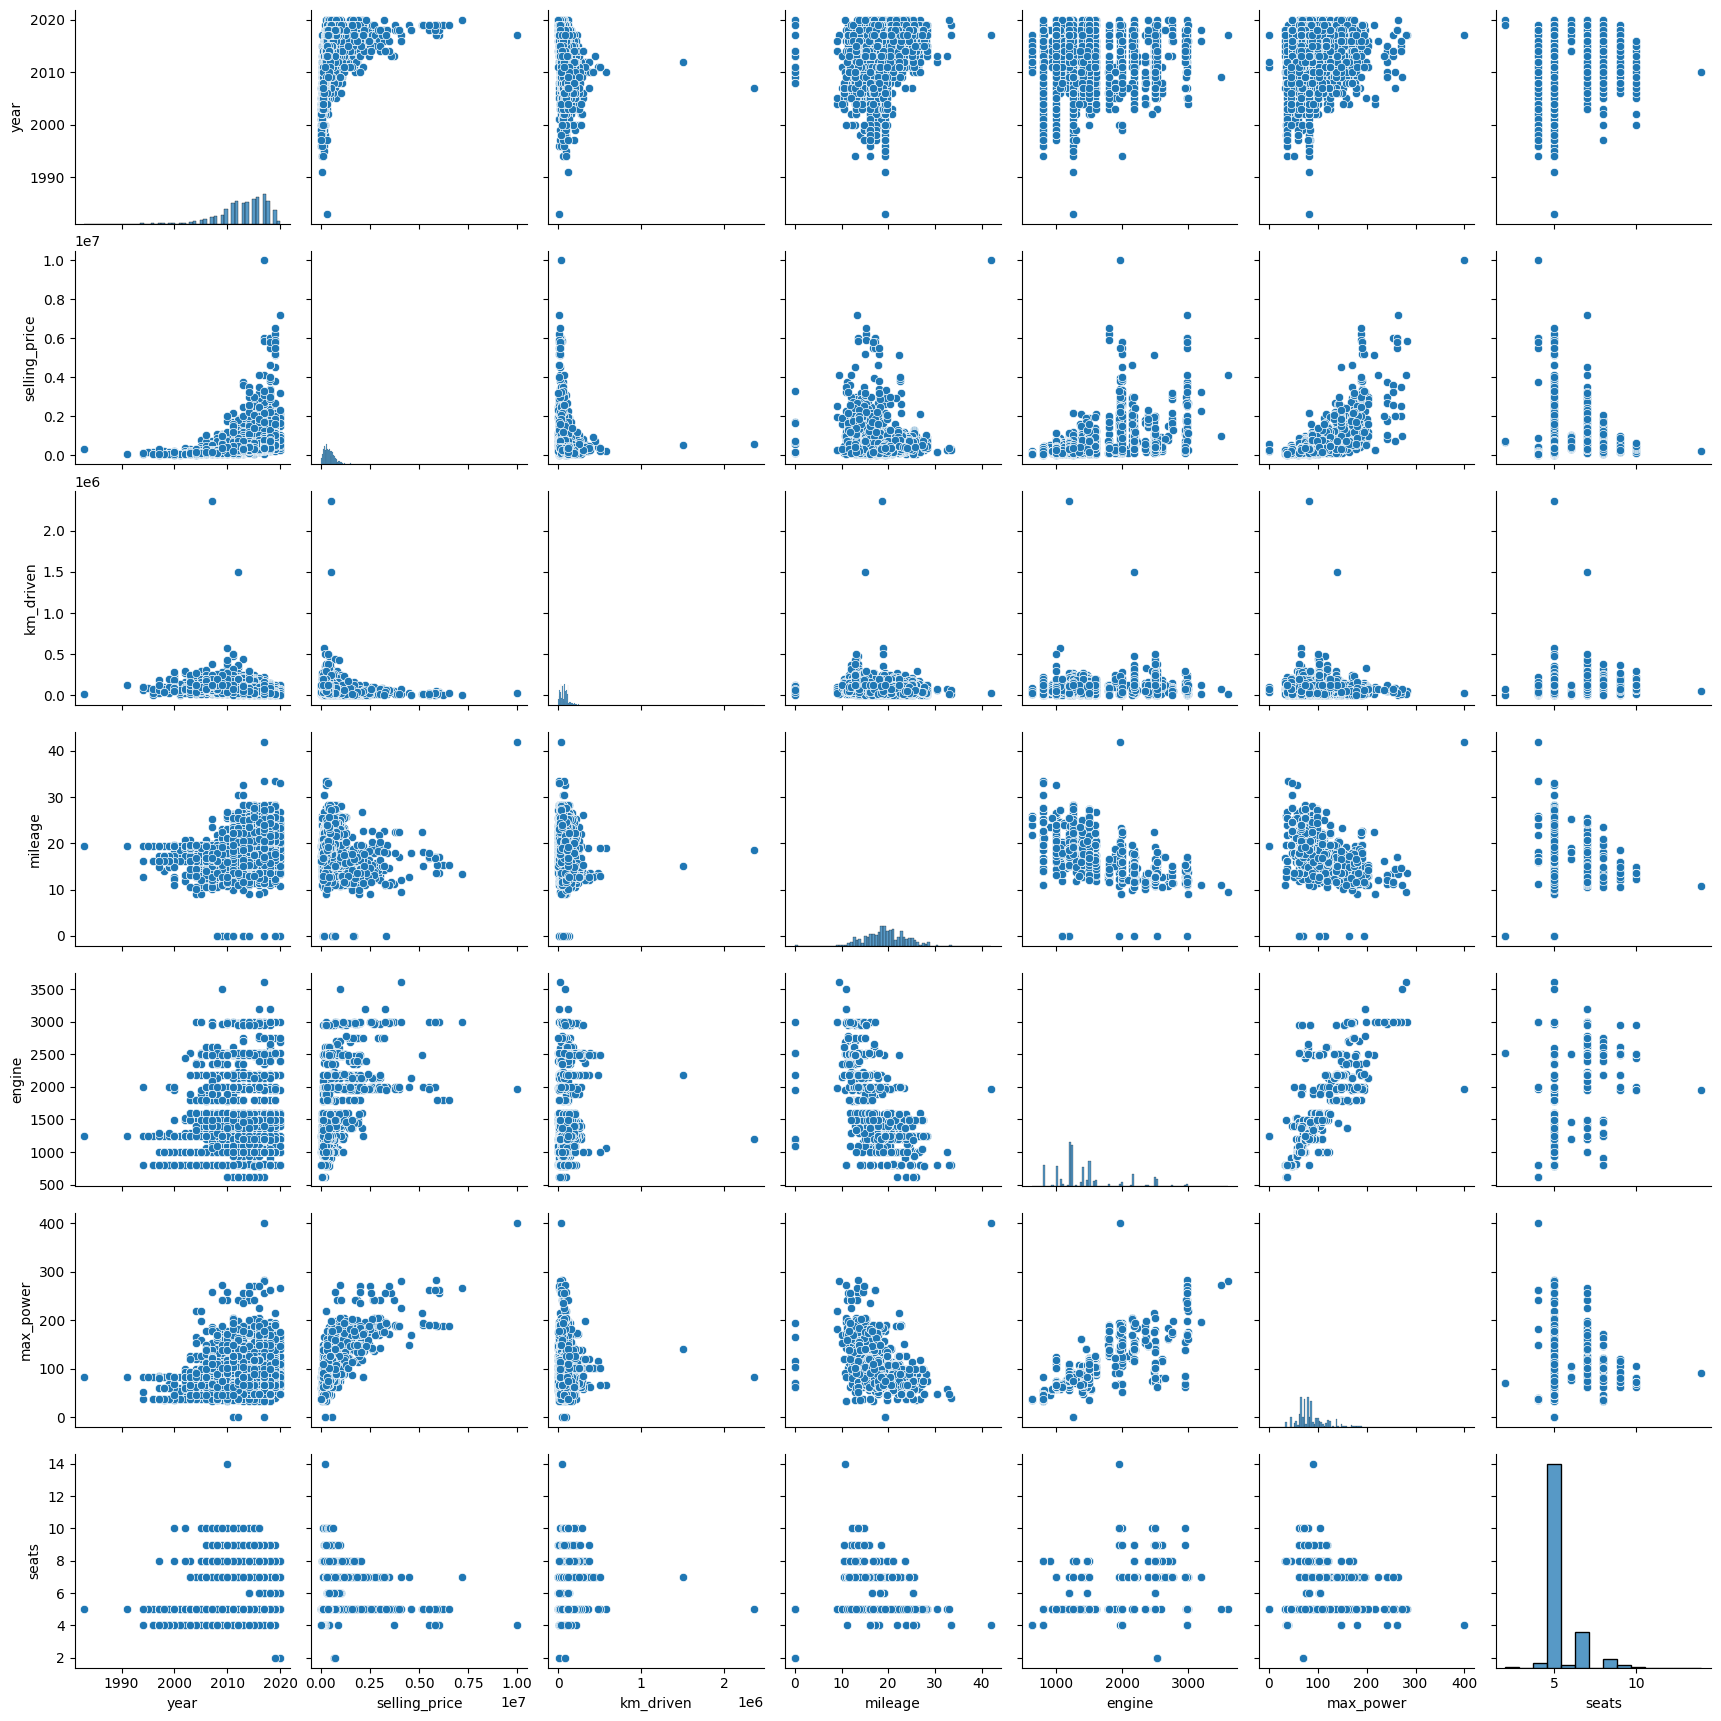

In [ ]:
sns.pairplot(df_train)

Можно предположить связь с целевой переменной у 4 признаков: год выпуска year, пробег km_driven и лошадиные силы max_power . Слабее связь с целевой переменной у объема двигателя engine. Между собой связаны мощность max_power и объем двигателя engine, объем двигателя engine и расход топлива mileage.

В целом, можно предположить и связь признаков с целевой переменной, и выдвинуть гипотезу о корреляциях признаков.

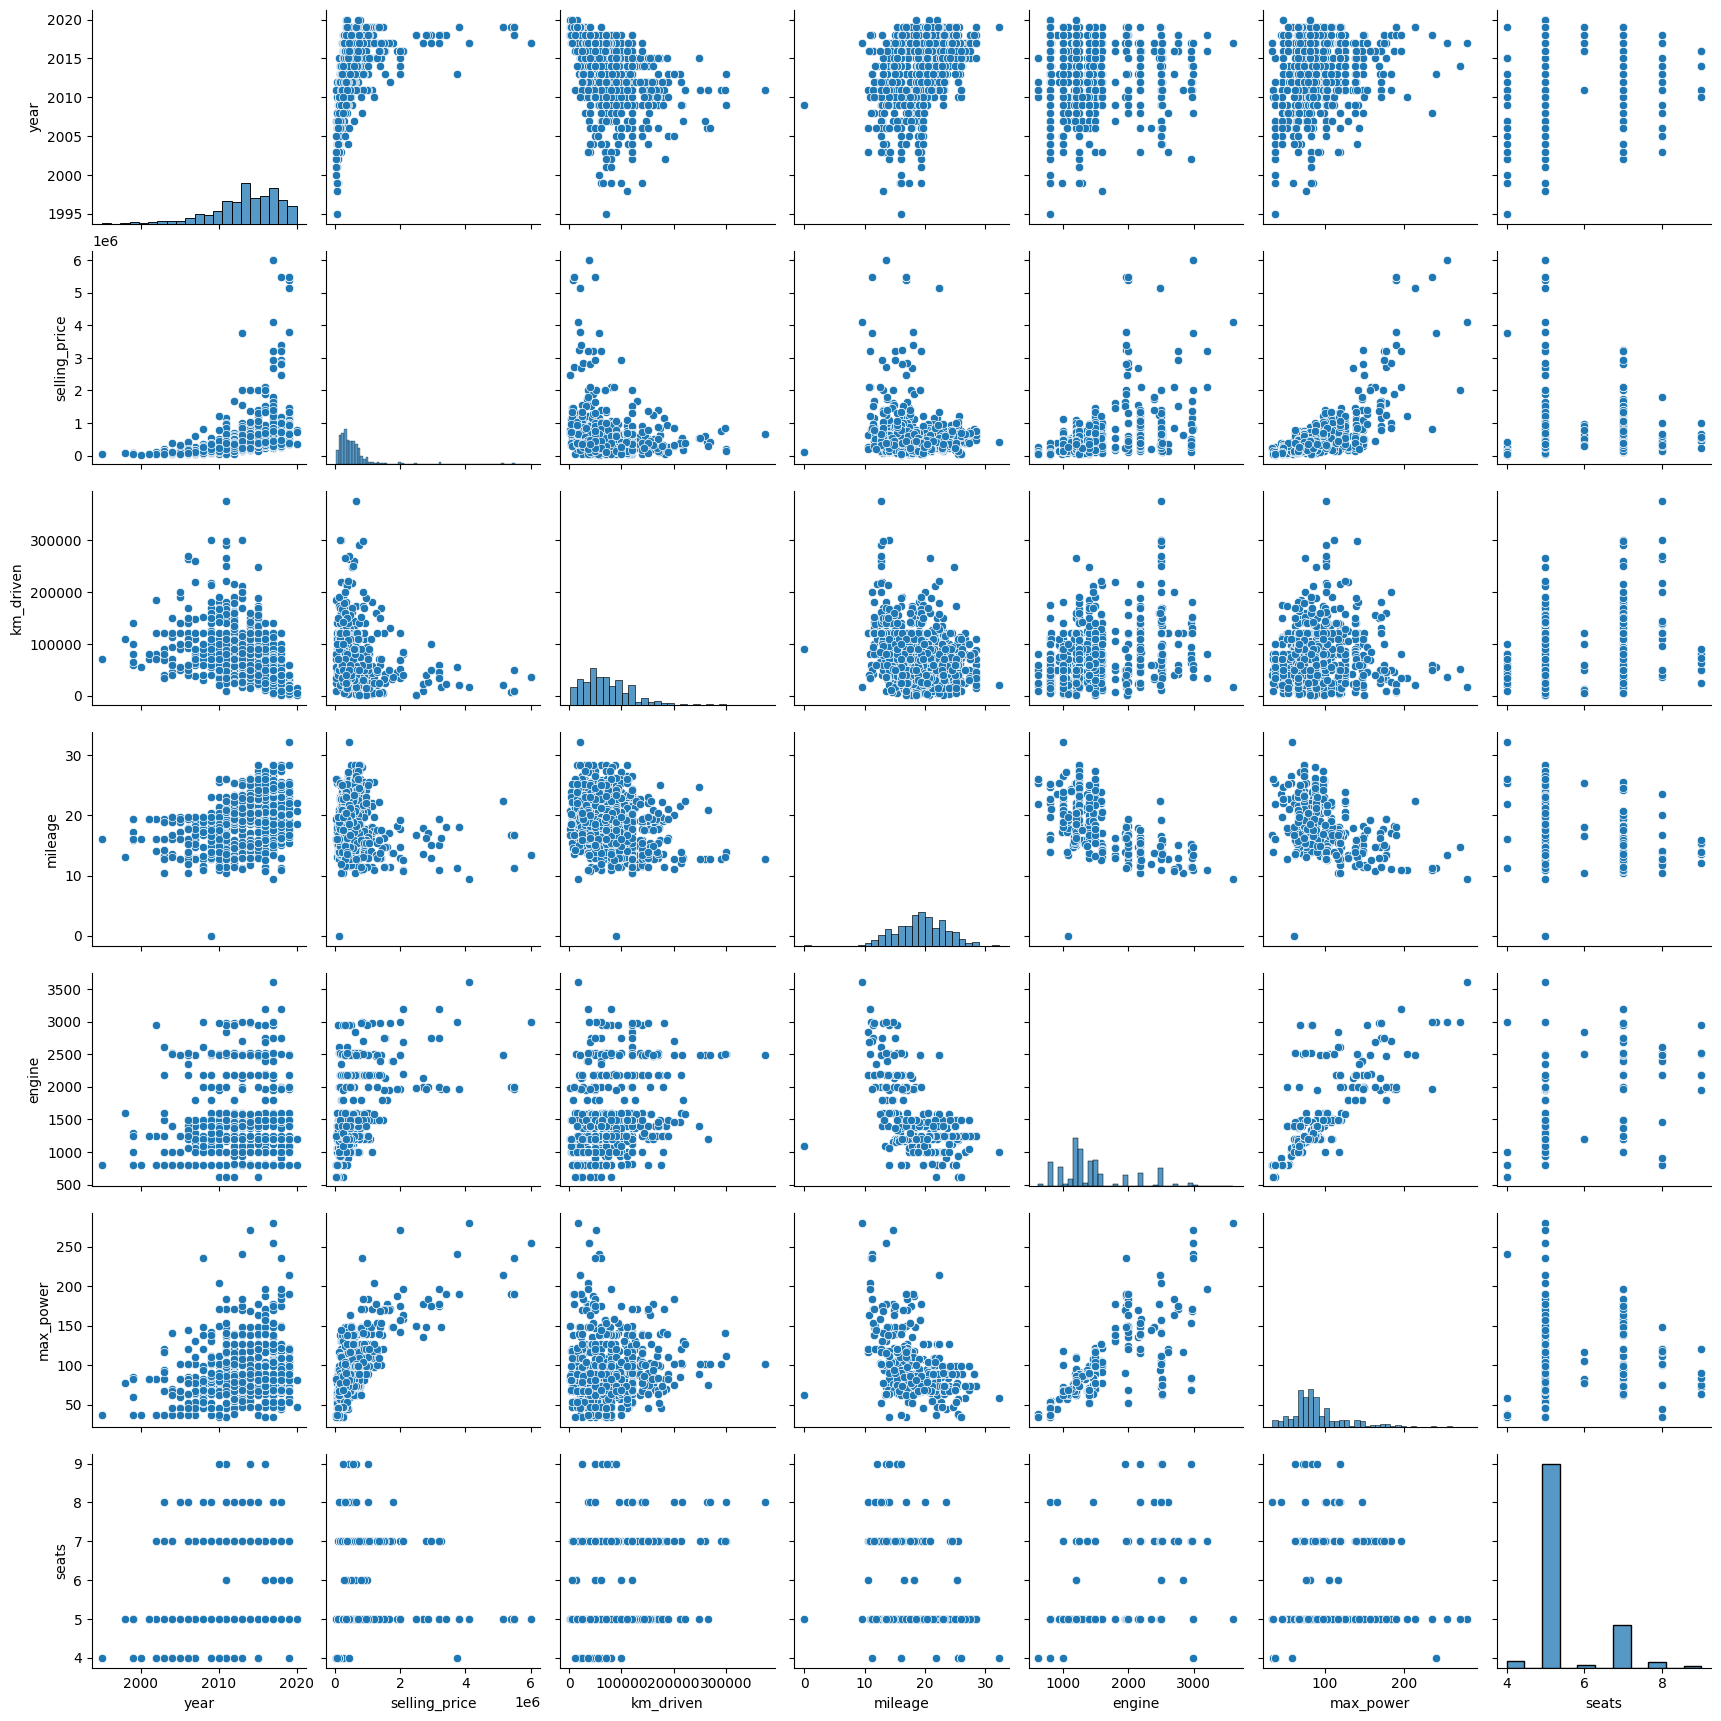

In [ ]:
sns.pairplot(df_test)

Совокупности похожи.

In [ ]:
df_train.corr(numeric_only = True)


,year,selling_price,km_driven,mileage,engine,max_power,seats
year,1.000000,0.427279,-0.368966,0.341334,0.002819,0.156858,0.041178
selling_price,0.427279,1.000000,-0.164828,-0.104769,0.447672,0.692814,0.149953
km_driven,-0.368966,-0.164828,1.000000,-0.182086,0.229766,0.024588,0.192328
mileage,0.341334,-0.104769,-0.182086,1.000000,-0.572893,-0.373390,-0.451059
engine,0.002819,0.447672,0.229766,-0.572893,1.000000,0.681117,0.652172
max_power,0.156858,0.692814,0.024588,-0.373390,0.681117,1.000000,0.244112
seats,0.041178,0.149953,0.192328,-0.451059,0.652172,0.244112,1.000000


<Axes: >

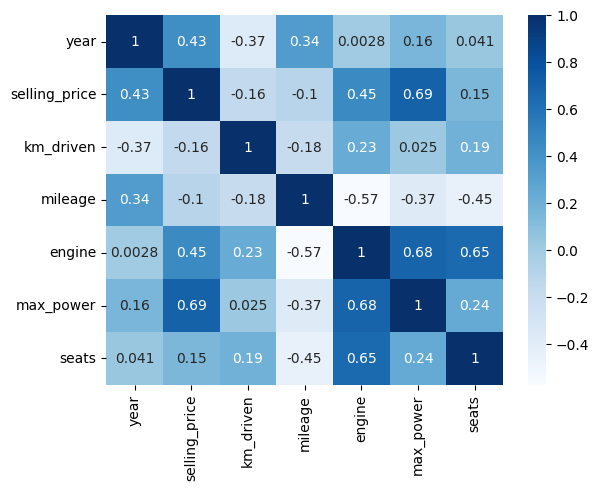

In [ ]:
sns.heatmap(df_train.corr(numeric_only = True), cmap="Blues", annot=True)

менее всего коррелируют engine и year. сильная положительная зависимость у selling price и max power. правильно, тк обратная связь присутствует.

# **Часть 2 | Модель только на вещественных признаках**


In [ ]:
y_train = df_train['selling_price'].copy()

categorical_columns = ['name', 'fuel', 'seller_type', 'transmission', 'owner']
numeral_columns = ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
X_train = df_train[numeral_columns].copy()

In [ ]:
y_test = df_test['selling_price'].copy()
X_test = df_test[numeral_columns].copy()

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

pred = model.predict(X_test)

print(f'''Metrics:
mse={MSE(y_test, pred)}
R2={r2_score(y_test, pred)}
''')

Metrics:
mse=233298786264.1253
R2=0.5941419681125487



In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model.fit(X_train_scaled, y_train)
pred2 = model.predict(X_test_scaled)

print(f'''Metrics:
mse={MSE(y_test, pred2)}
R2={r2_score(y_test, pred2)}
''')

Metrics:
mse=233298786264.12006
R2=0.5941419681125579



In [ ]:
X_train.columns[np.argmax(np.abs(model.coef_))]

'max_power'

In [ ]:
for a in np.arange(1e+3, 1e+4, 1000):
    lasso = Lasso(alpha=a, max_iter=10000, random_state=42)
    lasso.fit(X_train_scaled, y_train)

    pred3 = lasso.predict(X_test_scaled)

print(f'''Metrics:
mse={MSE(y_test, pred3)}
R2={r2_score(y_test, pred3)}
''')
print(np.sum(lasso.coef_ == 0))

Metrics:
mse=239919626343.75696
R2=0.5826240293903187

1


In [ ]:
print(X_train.columns[lasso.coef_ == 0])

Index(['seats'], dtype='object')


Один вес занулился. Я думаю, что количество мест не слишком влияет на предсказания, потому что большинство машин по 5 мест.

In [ ]:
params = {'alpha': [0.01, 0.1, 0.5, 1, 10]}

model = Lasso(max_iter=10000, random_state=42)

gs = GridSearchCV(model, params, cv=10, scoring='r2')
gs.fit(X_train_scaled, y_train)

pred4 = gs.best_estimator_.predict(X_test_scaled)

print(f'''Metrics:
mse={MSE(y_test, pred4)}
R2={r2_score(y_test, pred4)}
''')

Metrics:
mse=233305512404.08737
R2=0.594130266988977



In [ ]:
print(len(params['alpha']))
print(gs.best_params_['alpha'])
print(np.sum(gs.best_estimator_.coef_ == 0))

5
10
0


5 моделей, 10, веса не занулились

In [ ]:
params = {
    'alpha': [0.001, 0.01, 0.1, 0.5, 1, 10],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
}

model = ElasticNet(max_iter=10000, random_state=42)

gs = GridSearchCV(model, params, cv=10, scoring='r2')
gs.fit(X_train_scaled, y_train)

pred5 = gs.best_estimator_.predict(X_test_scaled)

print(f'''Metrics:
mse={MSE(y_test, pred5)}
R2={r2_score(y_test, pred5)}
''')


Metrics:
mse=252056406343.3623
R2=0.5615102905536573



In [ ]:
print(len(params['alpha']) * len(params['l1_ratio']) * 10)
print(gs.best_params_)

360
{'alpha': 0.5, 'l1_ratio': 0.7}


# **Часть 3| Добавляем категориальные фичи**


In [ ]:
top_names = df_train['name'].value_counts().index[:5].tolist()

def encode_name_top(name, top_set):
    return name if name in top_set else 'other'

df_train['name_top'] = df_train['name'].apply(lambda x: encode_name_top(x, top_names))
df_test['name_top'] = df_test['name'].apply(lambda x: encode_name_top(x, top_names))

df_train = pd.get_dummies(df_train, columns=['name_top'], prefix='name', drop_first=True)
df_test = pd.get_dummies(df_test, columns=['name_top'], prefix='name', drop_first=True)

df_train.drop('name', axis=1, inplace=True)
df_test.drop('name', axis=1, inplace=True)

In [ ]:
#assert X_train_cat.shape == (5840, 10)

In [ ]:
#X_train_cat.describe(include='object')

In [ ]:
categorical_features = ['seats'] + df_train.select_dtypes(include=['object']).columns.tolist()
categorical_features = list(set(categorical_features))

df_train = pd.get_dummies(df_train, columns=categorical_features, drop_first=True)
df_test = pd.get_dummies(df_test, columns=categorical_features, drop_first=True)

for col in df_train.columns:
    if col not in df_test.columns:
        df_test[col] = 0

df_test = df_test[df_train.columns]

In [ ]:
X_train = df_train.drop('selling_price', axis=1)
y_train = df_train['selling_price']
X_test = df_test.drop('selling_price', axis=1)
y_test = df_test['selling_price']

ridge = Ridge(random_state=42)

params_grid = {'alpha': [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100, 200, 500, 1000]}

grid_search = GridSearchCV(ridge, params_grid, cv=10, scoring='r2')
grid_search.fit(X_train, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

pred6 = grid_search.predict(X_test)

print(f'''Metrics:
mse={MSE(y_test, pred6)}
R2={r2_score(y_test, pred6)}
''')

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.05758e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


{'alpha': 5}
0.625900626084894
Metrics:
mse=205220715114.498
R2=0.6429879603205069



In [ ]:
def business_metric(y_true, y_pred):
    difference = np.abs((y_true - y_pred) / y_true)
    prices = difference <= 0.1
    return prices.mean()

print(
    business_metric(y_test, pred),
    business_metric(y_test, pred3),
    business_metric(y_test, pred4),
    business_metric(y_test, pred5),
    business_metric(y_test, pred6)
)

0.227 0.235 0.227 0.247 0.252


лучше всего решает задачу ridge

# **<font color="green">Часть 5 | Создание интерактивного приложения на Streamlit (3 балла)</font>**

Вам необходимо создать интерактивное приложение на Streamlit, которое будет:

- Показывать основные информативные графики/гистограммы в рамках EDA (1 балл)
- На вход запрашивать csv-файл с признаками объектов или запрашивать признаки объекта в окошках для ввода, и применять на поступивших объектах модель (1 балл)
- Визуализировать веса обученной модели (1 балл)

# **Часть 6 | Оформление репозитория и оценка сервиса (2 балла)**

**Результаты вашей работы** необходимо разместить в своём GitHub-репозитории. В этот же репозиторий позже будет добавлена вторая часть.

Под результатами первой части понимаем следующее:

---

### Обязательные файлы:

1. **`.ipynb`-ноутбук** со всеми экспериментами:

   * полный EDA,
   * все шаги препроцессинга,
   * обучение и сравнение моделей,
   * сохранённые output’ы.

2. **`.pickle`-файл**, содержащий:

   * обученную модель (или пайплайн `scaler + model`);
   * параметры скейлинга;
   * любые числовые объекты, необходимые для инференса внутри Streamlit-приложения.

3. **`.md`-файл с выводами** о проделанной работе:

   * что было сделано (краткое описание каждого этапа);
   * какие результаты были получены (метрики + интерпретация);
   * что дало наибольший прирост качества;
   * что сделать не удалось и почему (это нормально и даже полезно);
   * **оценка разработанного сервиса**:

     * насколько приложение удобно в использовании;
     * что получилось визуализировать хорошо, а что — менее удачно;
     * какие ограничения или проблемы вы заметили;
     * какие улучшения планируете в следующей итерации.

По результатам второй части, ждем:

4. **Streamlit-приложение** (например, `app.py`), которое можно запустить командой:

   ```bash
   streamlit run app.py
   ```

**И ссылку на приложение в StreamlitHub.**

В приложении должно быть:

* отображение ключевых графиков EDA;
* ввод данных (CSV или ручной ввод);
* применение модели;
* визуализация весов/коэффициентов.



### **За что могут быть сняты баллы:**

* отсутствие `.pickle` с моделью / пайплайном;
* слабая или неполная аналитика в `.md`-файле;
* беспорядок в ноутбуке или неясная логика вычислений;
* отсутствие возможности запустить Streamlit-приложение.